# IMPORTS

In [ ]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_recall_curve
)

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

!pip install gensim
from gensim.models import Word2Vec



from tensorflow.keras.layers import Input, Dense, Dropout, concatenate, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 54.4 MB/s eta 0:00:00


# LOAD DATA

In [ ]:
data = pd.read_csv("Preprocessed_DonorsChoose_dataset.csv")

print(data.shape)
data.head()
data['project_is_approved'].value_counts()

(11256, 14)


,count
project_is_approved,
1,9548
0,1708


# CONCATENATE ALL FEATURE COLUMNS

In [ ]:
X = data.drop(columns=['project_is_approved'])
y = data['project_is_approved']

data['combined_text'] = X.astype(str).agg(' '.join, axis=1)

# PREPROCESSING

In [ ]:
import pandas as pd
import string
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

def preprocess_text(text):
    if pd.isna(text):
        return []

    text = text.strip()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'[^a-zA-Z0-9 ]','',text)
    text = text.lower()

    tokens = nltk.word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    return tokens

data['tokens'] = data['combined_text'].apply(preprocess_text)
data['clean_text'] = data['tokens'].apply(lambda x: ' '.join(x))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# TRAIN TEST SPLIT (STRATIFIED)

In [ ]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    data['clean_text'],
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# TF-IDF (FIT ONLY ON TRAIN)

In [ ]:
tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=15000
)

X_tfidf_train = tfidf.fit_transform(X_train_text)
X_tfidf_test = tfidf.transform(X_test_text)

# WORD2VEC (TRAIN UNSUPERVISED)

In [ ]:
corpus = data['tokens'].tolist()

w2v_model = Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=3,
    min_count=1,
    workers=4,
    sg=1
)

def sentence_embedding(words):
    vectors = [w2v_model.wv[w] for w in words if w in w2v_model.wv]
    if len(vectors) == 0:
        return np.zeros(w2v_model.vector_size)
    return np.mean(vectors, axis=0)

X_w2v = np.array([sentence_embedding(tokens) for tokens in data['tokens']])

# Align with same split
X_w2v_train = X_w2v[X_train_text.index]
X_w2v_test = X_w2v[X_test_text.index]

# ***CLASSICAL ML MODELS***

## Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_tfidf_train, y_train)

y_pred_lr = lr.predict(X_tfidf_test)
y_prob_lr = lr.predict_proba(X_tfidf_test)[:,1]

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.28      0.44      0.34       342
           1       0.89      0.80      0.84      1910

    accuracy                           0.74      2252
   macro avg       0.58      0.62      0.59      2252
weighted avg       0.79      0.74      0.76      2252



## SVM

In [ ]:
svm = LinearSVC(class_weight='balanced')
svm.fit(X_tfidf_train, y_train)

y_pred_svm = svm.predict(X_tfidf_test)
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.28      0.32      0.30       342
           1       0.88      0.85      0.86      1910

    accuracy                           0.77      2252
   macro avg       0.58      0.59      0.58      2252
weighted avg       0.79      0.77      0.78      2252



## Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_tfidf_train, y_train)

y_pred_rf = rf.predict(X_tfidf_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       342
           1       0.85      1.00      0.92      1910

    accuracy                           0.85      2252
   macro avg       0.42      0.50      0.46      2252
weighted avg       0.72      0.85      0.78      2252



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## XGBoost

In [ ]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_tfidf_train, y_train)

y_pred_xgb = xgb.predict(X_tfidf_test)
y_prob_xgb = xgb.predict_proba(X_tfidf_test)[:,1]

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.27      0.27      0.27       342
           1       0.87      0.87      0.87      1910

    accuracy                           0.78      2252
   macro avg       0.57      0.57      0.57      2252
weighted avg       0.78      0.78      0.78      2252



# DEEP LEARNING (MULTI INPUT)

In [ ]:
X_tfidf_train_dense = X_tfidf_train.toarray()
X_tfidf_test_dense = X_tfidf_test.toarray()

input_tfidf = Input(shape=(X_tfidf_train_dense.shape[1],))
x1 = Dense(512, activation='relu',
           kernel_initializer='he_uniform',
           kernel_regularizer=regularizers.l2(0.001))(input_tfidf)
x1 = BatchNormalization()(x1)
x1 = Dropout(0.5)(x1)
x1 = Dense(256, activation='relu')(x1)

input_w2v = Input(shape=(X_w2v_train.shape[1],))
x2 = Dense(256, activation='relu')(input_w2v)
x2 = BatchNormalization()(x2)
x2 = Dropout(0.4)(x2)

merged = concatenate([x1, x2])
x = Dense(256, activation='relu')(merged)
x = Dropout(0.4)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=[input_tfidf, input_w2v], outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)

model.fit(
    [X_tfidf_train_dense, X_w2v_train],
    y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=256,
    callbacks=[early_stop, reduce_lr]
)

pred_probs_dl = model.predict([X_tfidf_test_dense, X_w2v_test]).ravel()
pred_labels_dl = (pred_probs_dl > 0.5).astype(int)

print(classification_report(y_test, pred_labels_dl))

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 464ms/step - accuracy: 0.6919 - loss: 1.4378 - val_accuracy: 0.8502 - val_loss: 1.2077 - learning_rate: 5.0000e-04
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 331ms/step - accuracy: 0.8584 - loss: 0.8764 - val_accuracy: 0.8502 - val_loss: 0.9877 - learning_rate: 5.0000e-04
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 332ms/step - accuracy: 0.9242 - loss: 0.6179 - val_accuracy: 0.8502 - val_loss: 0.7881 - learning_rate: 5.0000e-04
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 329ms/step - accuracy: 0.9833 - loss: 0.4250 - val_accuracy: 0.8502 - val_loss: 0.7558 - learning_rate: 5.0000e-04
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 327ms/step - accuracy: 0.9928 - loss: 0.3416 - val_accuracy: 0.8502 - val_loss: 0.7627 - learning_rate: 5.0000e-04
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 282ms/step - accuracy: 0.9962 - loss: 0.2841 - val_accuracy: 0.8502 - val_loss: 0.7673 - learning_rate: 5.0000e-04
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 278ms/step - accu

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# ROC & PRECISION-RECALL CURVES

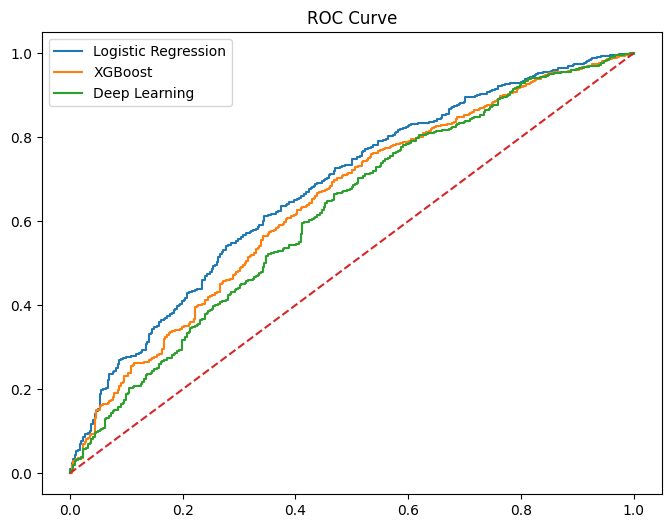

In [ ]:
plt.figure(figsize=(8,6))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
plt.plot(fpr_lr, tpr_lr, label='Logistic Regression')

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
plt.plot(fpr_xgb, tpr_xgb, label='XGBoost')

fpr_dl, tpr_dl, _ = roc_curve(y_test, pred_probs_dl)
plt.plot(fpr_dl, tpr_dl, label='Deep Learning')

plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

# MODEL COMPARISON TABLE

In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Random Forest", "XGBoost", "Deep Learning"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, pred_labels_dl)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, pred_labels_dl)
    ]
})

results

,Model,Accuracy,F1 Score
0,Logistic Regression,0.741563,0.839404
1,SVM,0.772647,0.864263
2,Random Forest,0.848135,0.917828
3,XGBoost,0.776643,0.868083
4,Deep Learning,0.848135,0.917828


# **Strengths and Weaknesses**
## **Logistic Regression**

### **Strengths**

Fast training

Strong baseline

Interpretable coefficients

Works well with TF-IDF

### **Weaknesses**

Linear decision boundary

Limited interaction modeling

## **Support Vector Machine**

### Strengths

Strong margin-based classifier

Robust in high-dimensional spaces

### Weaknesses

Limited probability output (LinearSVC)

Computational cost for large datasets

## **Random Forest**

### Strengths

Captures nonlinear interactions

Robust to noise

### Weaknesses

Struggles with sparse high-dimensional TF-IDF

Less efficient compared to linear models in text classification

# XGBoost

## Strengths

Powerful gradient boosting framework

Handles feature interactions

Performs well after tuning

## Weaknesses

Computationally expensive

Gains limited in purely sparse lexical tasks

## Deep Learning (Functional API Multi-Input Model)

### Strengths

Integrates multiple embedding approaches

Learns nonlinear hierarchical representations

Flexible architecture

### Weaknesses

Requires tuning (learning rate, dropout, architecture)

Higher computational cost

Risk of overfitting without regularization

# Reasons for Performance Differences

High-Dimensional Sparsity

TF-IDF produces thousands of sparse features.

Linear models handle sparse features efficiently.

Semantic Representation

Word2Vec captures contextual similarity.

Averaged embeddings lose term frequency weighting.

Feature Interactions

Tree-based models capture interactions.

Deep learning learns nonlinear combinations.

Class Imbalance

Impacts recall and F1-score.

Requires class weighting and threshold optimization.

# Potential Improvements

TF-IDF weighted Word2Vec averaging

Custom Word2Vec training with larger vector size

Integration of numerical metadata as third input branch

Transformer-based contextual embeddings (BERT)

Focal loss for imbalance

Hyperparameter search using Bayesian optimization

Dimensionality reduction before tree-based models




## The experimental results demonstrate that:

Classical linear models (Logistic Regression, SVM) remain highly competitive for sparse TF-IDF based text classification.

Random Forest and XGBoost provide improvements when nonlinear feature interactions are relevant.

The deep learning Functional API model integrating multiple embedding inputs offers enhanced representation capacity but requires careful regularization and tuning.

In high-dimensional text classification tasks, simpler linear models often achieve comparable or superior performance relative to more complex architectures.

## Model selection should consider:

Predictive performance

Computational efficiency

Interpretability

Deployment constraints